# Final test to use PCA-compression class

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import importlib
import os
import sys
import time
from pathlib import Path
from IPython.display import display, clear_output

In [6]:
ROOT = Path.cwd().parent
ROOT

PosixPath('/Users/debabrata/Documents/conferences/India/codes/WORKSHOP_MATERIALS')

In [18]:
data_path=ROOT.joinpath("data/") #Path('/Users/debabrata/Documents/conferences/India/codes/WORKSHOP_MATERIALS/data/')

In [16]:
data_path

PosixPath('/Users/debabrata/Documents/conferences/India/codes/WORKSHOP_MATERIALS/data')

In [17]:
# one file with training parameters
training_parameters_1 = np.load(str(data_path /'camb_TTEETE_training_params_1.npz'))
# training features in this file
training_features_1 = np.load(str(data_path /'./camb_TT_training_log_spectra_1.npz'))


In [19]:
print("training paramters:",training_parameters_1.files,  "and", "Training data:",training_features_1.files)
ell_range=training_features_1['modes']

training paramters: ['omega_b', 'omega_cdm', 'h', 'n_s', 'ln10^{10}A_s', 'tau_reio'] and Training data: ['modes', 'features']


'modes': Multipole $\ell$ and 'features': log-spectrum


# Give parameters array at any order

This example uses a set of 6 standard $\Lambda$CDM parameters,

$\omega_{\mathrm{b}}, \omega_{\mathrm{cdm}}, h, \tau, n_s, \ln10^{10}A_s$

If your model is other than $\Lambda$CDM, use the same parameters name you used to save them in dict.

Names can be given in any order, internal function in PCA will rearrange them before any operation

In [20]:

model_parameters = ['h', 
                    'tau_reio', 
                    'omega_b', 
                    'n_s', 
                    'ln10^{10}A_s', 
                    'omega_cdm', 
                    ]

### **NUMBER OF PCA COMPONENTS**

In [21]:
n_pcas = 64

# Give the training samples in batches to use optimal memory, We will use IncrementalPCA in batches  

In [22]:
## path of samples
parameters_filenames = [str(data_path / "camb_TTEETE_training_params_1"),str(data_path / "camb_TTEETE_training_params_2"),]
            
features_filenames = [str(data_path / 'camb_TT_training_log_spectra_1'),str(data_path / 'camb_TT_training_log_spectra_2'),]

Lets call PCA class

In [23]:
sys.path.append("../src/")
import PCA_compression
importlib.reload(PCA_compression)

cp_pca = PCA_compression.PCA(parameters_name=model_parameters,
                        modes=ell_range,
                        n_pcas=n_pcas,
                        parameters_filenames=parameters_filenames,
                        features_filenames=features_filenames,
                        verbose=True, )


Initialized PCA compression with 64 components with given inputs



In [24]:
cp_pca.transform_and_stack_training_data()

starting PCA compression
Lets initialise the mean, std of features and parameters and compute PCA eigen-vectors

 mean and standard deviation computation is done



100%|████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:24<00:00, 12.03s/it]


PCA compression done and saved
parameters and PCA coefficients of training set stored in memory


# Tutorial-I: write a block here to validate the pca coefficient to check the pca coefficients reconstruct the original power spectra

In [25]:
# checking that we are using a GPU
device = 'gpu:0' if tf.test.is_gpu_available() else 'cpu'
print('using', device, 'device \n')

Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.
using gpu:0 device 



2026-09-03 11:18:19.665425: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2 Pro
2026-09-03 11:18:19.665537: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-09-03 11:18:19.665637: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-09-03 11:18:19.666273: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-09-03 11:18:19.666811: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [26]:
import PCA_emulator
importlib.reload(PCA_emulator)


<module 'PCA_emulator' from '/Users/debabrata/Documents/conferences/India/codes/WORKSHOP_MATERIALS/notebook/../src/PCA_emulator.py'>

In [27]:
cp_pca_nn = PCA_emulator.PCAplusNN(cp_pca=cp_pca,
                                 n_hidden=[512,512,512,512], # 4 hidden layers, each with 512 nodes
                                 verbose=True, # useful to understand the different steps in initialisation and training
                                 )


Initialized PCAplusNN model, 
The model maps 6 input parameters to 64 PCA coefficients 
and then invert the PCA coefficients to obtain power spectrum for 2507 modes 
The model uses 4 hidden layers, 
with [512, 512, 512, 512] neuron, respectively. 



2026-09-03 11:18:22.679530: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-09-03 11:18:22.679588: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


# Lets check if training is happeing ?

In [28]:
with tf.device(device):
    # train
    cp_pca_nn.train(filename_saved_model='../data/TT_cp_PCAplusNN_example_short_run',
                    # cooling schedule
                    validation_split=0.1,
                    learning_rates=[1e-2,  1e-6],
                    batch_sizes=[1024, 1024],
                    gradient_accumulation_steps = [1, 1],
                    # early stopping set up
                    patience_values = [100,100],
                    max_epochs = [10,10],
                    )

Starting PCAplusNN training, 
using 10 per cent of training samples for validation. 
Performing training with   2 learning steps, with 
[0.01, 1e-06] trailing learning rates 
[1024, 1024] batch sizes 
[1, 1] gradient accumulation steps (this function is not defined ) 
Recommend to use gradient_accumulation_steps = [1] for all learning steps
[100, 100] patience values 
[10, 10] max epochs 

learning rate = 0.01, batch size = 1024


  0%|                                                                                               | 0/10 [00:00<?, ?it/s]/Users/debabrata/anaconda3/envs/my_emulator/lib/python3.11/site-packages/keras/src/initializers/initializers.py:120: UserWarning: The initializer RandomNormal is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(
2026-09-03 11:18:25.425360: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-03 11:18:25.963269: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-09-03 11:18:26.248494: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type 

Reached max number of epochs. Validation loss = 262.10135
Model saved.
Training and validation loss are saved.
learning rate = 1e-06, batch size = 1024


100%|████████████████████████████████████████████████████████████████████████████| 10/10 [00:01<00:00,  5.15it/s, loss=215]


Reached max number of epochs. Validation loss = 214.86491
Model saved.
Training and validation loss are saved.


In [60]:
# lets check the architecture of the NN and trainable parameters

In [65]:
for i, var in enumerate(cp_pca_nn.network.trainable_variables):
    print( var.name, var.shape)

dense_0/kernel:0 (6, 512)
dense_0/bias:0 (512,)
activation_0/alpha:0 (512,)
activation_0/beta:0 (512,)
dense_1/kernel:0 (512, 512)
dense_1/bias:0 (512,)
activation_1/alpha:0 (512,)
activation_1/beta:0 (512,)
dense_2/kernel:0 (512, 512)
dense_2/bias:0 (512,)
activation_2/alpha:0 (512,)
activation_2/beta:0 (512,)
dense_3/kernel:0 (512, 512)
dense_3/bias:0 (512,)
activation_3/alpha:0 (512,)
activation_3/beta:0 (512,)
dense_4/kernel:0 (512, 64)
dense_4/bias:0 (64,)


# Run the training for larger epochs 

In [66]:
# ==========================================
# Start timing
# ==========================================

start_time = time.perf_counter()
with tf.device(device):
    # train
    cp_pca_nn.train(filename_saved_model='../data/TT_cp_PCAplusNN_example_large_check',
                    # cooling schedule
                    validation_split=0.1,
                    learning_rates=[1e-2, 1e-3, 1e-4, 1e-5, 1e-6],
                    batch_sizes=[1024, 1024, 1024, 1024, 1024],
                    gradient_accumulation_steps = [1, 1, 1, 1, 1],
                    # early stopping set up
                    patience_values = [100,100,100,100,100],
                    max_epochs = [1000,1000,1000,1000,1000],
                    )
end_time = time.perf_counter()

elapsed_time = end_time - start_time
print("time spent:",elapsed_time)

Starting PCAplusNN training, 
using 10 per cent of training samples for validation. 
Performing training with   5 learning steps, with 
[0.01, 0.001, 0.0001, 1e-05, 1e-06] trailing learning rates 
[1024, 1024, 1024, 1024, 1024] batch sizes 
[1, 1, 1, 1, 1] gradient accumulation steps (this function is not defined ) 
Recommend to use gradient_accumulation_steps = [1] for all learning steps
[100, 100, 100, 100, 100] patience values 
[1000, 1000, 1000, 1000, 1000] max epochs 

learning rate = 0.01, batch size = 1024


 74%|████████████████████████████████████████████████████████████▌                     | 738/1000 [02:27<00:52,  5.00it/s, loss=0.147]


Reached early stop criteria at epoch: 738.Validation loss = 0.04358939826488495
Model saved.
Training and validation loss are saved.
Reached max number of epochs. Validation loss = 0.0435894
Model saved.
Training and validation loss are saved.
learning rate = 0.001, batch size = 1024


 20%|████████████████                                                                | 201/1000 [00:41<02:45,  4.83it/s, loss=0.00772]


Reached early stop criteria at epoch: 201.Validation loss = 0.006267837714403868
Model saved.
Training and validation loss are saved.
Reached max number of epochs. Validation loss = 0.0062678377
Model saved.
Training and validation loss are saved.
learning rate = 0.0001, batch size = 1024


...

Reached max number of epochs. Validation loss = 0.002502951
Model saved.
Training and validation loss are saved.
learning rate = 1e-05, batch size = 1024


 10%|████████▏                                                                        | 101/1000 [00:22<03:20,  4.49it/s, loss=0.0024]


Reached early stop criteria at epoch: 101.Validation loss = 0.0023947195149958134
Model saved.
Training and validation loss are saved.
Reached max number of epochs. Validation loss = 0.0023947195
Model saved.
Training and validation loss are saved.
learning rate = 1e-06, batch size = 1024


 10%|████████                                                                         | 100/1000 [00:21<03:13,  4.64it/s, loss=0.0024]

Reached early stop criteria at epoch: 100.Validation loss = 0.0023937076330184937
Model saved.
Training and validation loss are saved.
Reached max number of epochs. Validation loss = 0.0023937076
Model saved.
Training and validation loss are saved.
time spent: 450.2845412910028


# Plot validation and training losses

[738. 201. 999. 101. 100.]


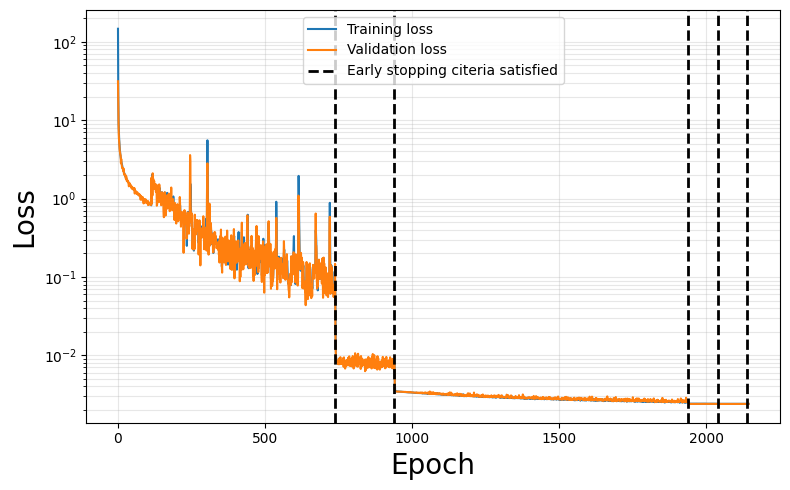

In [67]:

filename_saved_model = "../data/TT_cp_PCAplusNN_example_large_check"

history = np.load(
    filename_saved_model + "_history.npz"
)

early_stops=np.loadtxt(filename_saved_model + "early_stop_epochs.txt") #[481,250,1000,670,99]
print(early_stops)
training_loss = history["training_loss"]
validation_loss = history["validation_loss"]

plt.figure(figsize=(8, 5))

plt.plot(
    training_loss[1:],
    label="Training loss"
)

plt.plot(
    validation_loss[1:],
    label="Validation loss"
)
pr=0
t=0
for x in early_stops:
    pr=pr+x
    if (t==0):
        plt.axvline(x=pr, color='k',lw=2,ls='--',label='Early stopping citeria satisfied')
    else:
        plt.axvline(x=pr, color='k',lw=2,ls='--',)
    t+=1
plt.xlabel("Epoch",fontsize=20)
plt.ylabel("Loss",fontsize=20)

plt.yscale("log")

plt.legend()
plt.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

# TESTING

We will load the pretrained weights and emulate the power spectrum from testing samples

In [29]:
# testing parameters
testing_params = np.load(str(data_path /'./camb_TTEETE_training_params_3.npz'))
# testing features
#testing_spectra = 10.**np.load(str(data_path /'./camb_TT_training_log_spectra_3.npz'))['features'] 
testing_spectra = np.load(str(data_path /'./camb_TT_training_log_spectra_3.npz'))['features'] 

In [32]:
cp_pca_nn = PCA_emulator.PCAplusNN(restore=True, 
                                 restore_filename='../data/TT_cp_PCAplusNN_example_large'
                                 )     

In [33]:
#predicted_testing_spectra = cp_pca_nn.ten_to_predictions_np(testing_params) #prediction.numpy()
predicted_testing_spectra = cp_pca_nn.predictions_np(testing_params) #prediction.numpy()

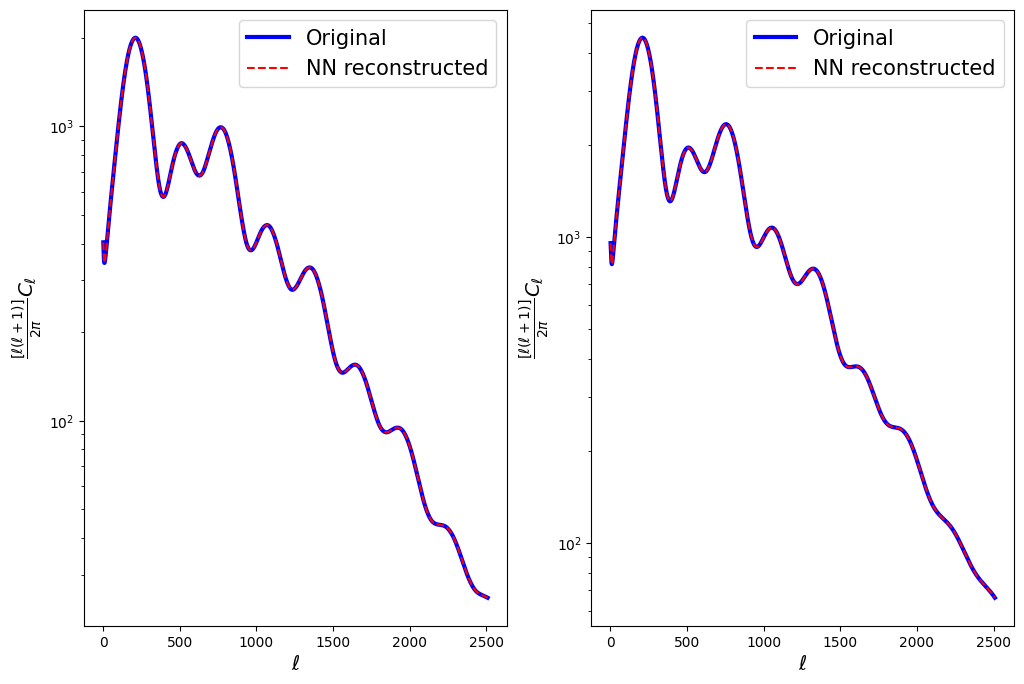

In [34]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12,8))
s=0
factor=(2.7255e6)**2
for i in range(2,4):
    pred = factor*10**(predicted_testing_spectra[i])*ell_range*(ell_range+1)/(2.*np.pi)
    true = factor*10**testing_spectra[i]*ell_range*(ell_range+1)/(2.*np.pi)
    ax[s].semilogy(ell_range, true, 'blue', label = 'Original',lw=3)
    ax[s].semilogy(ell_range, pred, 'red', label = 'NN reconstructed', linestyle='--')
    ax[s].set_xlabel('$\ell$', fontsize='x-large')
    ax[s].set_ylabel('$\\frac{[\ell(\ell+1)]}{2 \pi} C_\ell$', fontsize='x-large')
    ax[s].legend(fontsize=15)
    
    #ax[s].set_ylim([0,2e-7])
    s=s+1
#plt.savefig('examples_reconstruction_TT.pdf')


# Tutorial-2: Compare EE and TE also
The pretrained networks are given in the data folder
Note: Since TE has negative values, I do not use log for it. Therefore do not convert it with 10^{--}  

In [86]:
"""
testing_spectra = np.load(str(data_path /'./camb_TE_training_log_spectra_3.npz'))['features'] 
cp_pca_nn = PCA_emulator.PCAplusNN(restore=True, 
                                 restore_filename='../data/TE_cp_PCAplusNN_example_large'
                                 ) 
predicted_testing_spectra = cp_pca_nn.predictions_np(testing_params) #prediction.numpy()
"""

"\ntesting_spectra = np.load(str(data_path /'./camb_TE_training_log_spectra_3.npz'))['features'] \ncp_pca_nn = PCA_emulator.PCAplusNN(restore=True, \n                                 restore_filename='../data/TE_cp_PCAplusNN_example_large'\n                                 ) \npredicted_testing_spectra = cp_pca_nn.predictions_np(testing_params) #prediction.numpy()\n"

In [85]:
"""
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12,8))
s=0
factor=(2.7255e6)**2
for i in range(2,4):
    pred = factor*(predicted_testing_spectra[i])*ell_range*(ell_range+1)/(2.*np.pi)
    true = factor*testing_spectra[i]*ell_range*(ell_range+1)/(2.*np.pi)
    ax[s].semilogx(ell_range, true, 'blue', label = 'Original',lw=3)
    ax[s].semilogx(ell_range, pred, 'red', label = 'NN reconstructed', linestyle='--')
    ax[s].set_xlabel('$\ell$', fontsize='x-large')
    ax[s].set_ylabel('$\\frac{[\ell(\ell+1)]}{2 \pi} C_\ell$', fontsize='x-large')
    ax[s].legend(fontsize=15)
    
    #ax[s].set_ylim([0,2e-7])
    s=s+1
#plt.savefig('examples_reconstruction_TE.pdf')
"""

"\nfig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12,8))\ns=0\nfactor=(2.7255e6)**2\nfor i in range(2,4):\n    pred = factor*(predicted_testing_spectra[i])*ell_range*(ell_range+1)/(2.*np.pi)\n    true = factor*testing_spectra[i]*ell_range*(ell_range+1)/(2.*np.pi)\n    ax[s].semilogx(ell_range, true, 'blue', label = 'Original',lw=3)\n    ax[s].semilogx(ell_range, pred, 'red', label = 'NN reconstructed', linestyle='--')\n    ax[s].set_xlabel('$\\ell$', fontsize='x-large')\n    ax[s].set_ylabel('$\\frac{[\\ell(\\ell+1)]}{2 \\pi} C_\\ell$', fontsize='x-large')\n    ax[s].legend(fontsize=15)\n\n    #ax[s].set_ylim([0,2e-7])\n    s=s+1\n#plt.savefig('examples_reconstruction_TE.pdf')\n"

# Tutorial-3: Train the same NN for lensing
You can 

In [115]:
print(cp_pca_nn.parameters)

ListWrapper(['h', 'tau_reio', 'omega_b', 'n_s', 'ln10^{10}A_s', 'omega_cdm'])


In [196]:
# testing parameters
testing_params = np.load(str(data_path /'./camb_pp_testing_params.npz'))
# testing features
testing_spectra = 10.**np.load(str(data_path /'./camb_pp_testing_log_spectra.npz'))['features'] # sampled modes are same as in training files. Transofrm log -> spectra as we only use these for testing

In [165]:
# testing parameters
testing_params = np.load(str(data_path /'./camb_pp_training_params_1.npz'))
# testing features
testing_spectra = 10.**np.load(str(data_path /'./camb_pp_training_log_spectra_1.npz'))['features'] # sampled modes are same as in training files. Transofrm log -> spectra as we only use these for testing

In [166]:
print(np.shape(testing_spectra), testing_params['h'].shape) 

(15000, 2507) (15000,)


In [212]:
import PCA_emulator
importlib.reload(PCA_emulator)
cp_pca_nn = PCA_emulator.cosmopower_PCAplusNN(restore=True, 
                                 restore_filename='PP_cp_PCAplusNN_example_large'
                                 )          
#prdicted_power = cp_pca_nn.ten_to_predictions_tf(testing_params)

In [168]:
print(cp_pca_nn.parameters)

ListWrapper(['h', 'tau_reio', 'omega_b', 'n_s', 'ln10^{10}A_s', 'omega_cdm'])


In [110]:
testing_params.files

['omega_b', 'omega_cdm', 'h', 'tau_reio', 'n_s', 'ln10^{10}A_s']

In [141]:
parameters_dict = {
    'h': np.array([0.675]),
    'tau_reio': np.array([0.054]),
    'omega_b': np.array([0.0224]),
    'n_s': np.array([0.965]),
    'ln10^{10}A_s': np.array([3.04]),
    'omega_cdm': np.array([0.12])
}

In [200]:
prediction = cp_pca_nn.predictions_tf(testing_params)

In [213]:
predicted_testing_spectra = cp_pca_nn.ten_to_predictions_np(testing_params) #prediction.numpy()

In [206]:
prediction.shape

TensorShape([9531, 2507])

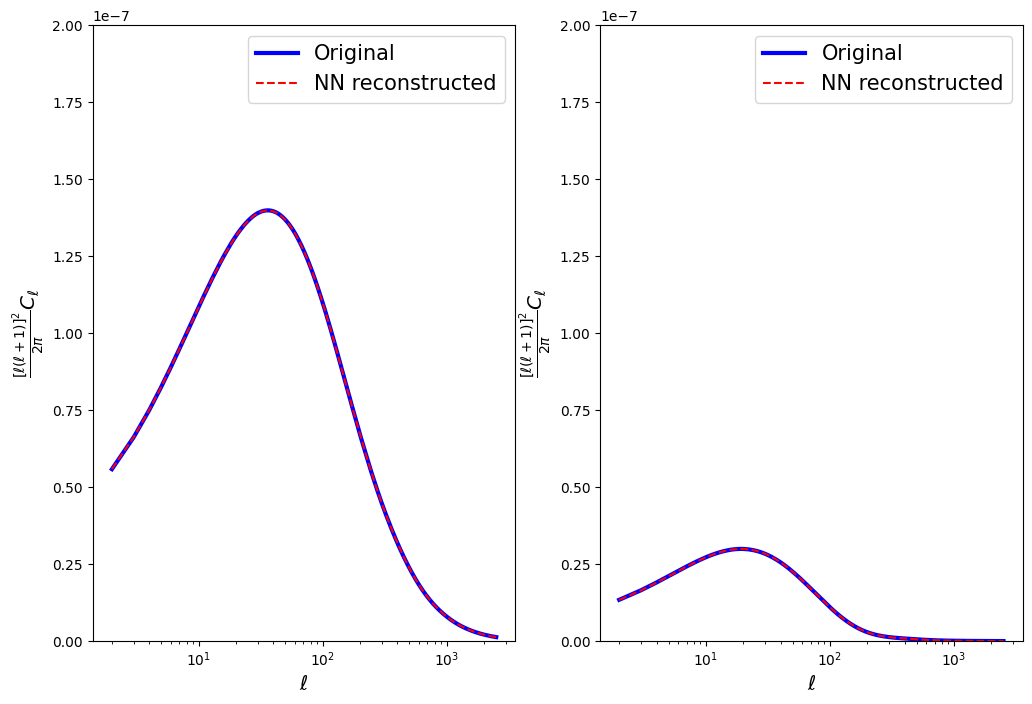

In [214]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12,8))
s=0
for i in range(20,22):
    pred = (predicted_testing_spectra[i])*ell_range*ell_range*(ell_range+1)*(ell_range+1)/(2.*np.pi)
    true = testing_spectra[i]*ell_range*ell_range*(ell_range+1)*(ell_range+1)/(2.*np.pi)
    ax[s].semilogx(ell_range, true, 'blue', label = 'Original',lw=3)
    ax[s].semilogx(ell_range, pred, 'red', label = 'NN reconstructed', linestyle='--')
    ax[s].set_xlabel('$\ell$', fontsize='x-large')
    ax[s].set_ylabel('$\\frac{[\ell(\ell+1)]^2}{2 \pi} C_\ell$', fontsize='x-large')
    ax[s].legend(fontsize=15)
    ax[s].set_ylim([0,2e-7])
    s=s+1
plt.savefig('examples_reconstruction_PP.pdf')

In [191]:
for i, var in enumerate(cp_pca_nn.network.trainable_variables):
    print(i, var.name, var.shape)

0 dense_0/kernel:0 (6, 512)
1 dense_0/bias:0 (512,)
2 activation_0/alpha:0 (512,)
3 activation_0/beta:0 (512,)
4 dense_1/kernel:0 (512, 512)
5 dense_1/bias:0 (512,)
6 activation_1/alpha:0 (512,)
7 activation_1/beta:0 (512,)
8 dense_2/kernel:0 (512, 512)
9 dense_2/bias:0 (512,)
10 activation_2/alpha:0 (512,)
11 activation_2/beta:0 (512,)
12 dense_3/kernel:0 (512, 512)
13 dense_3/bias:0 (512,)
14 activation_3/alpha:0 (512,)
15 activation_3/beta:0 (512,)
16 dense_4/kernel:0 (512, 64)
17 dense_4/bias:0 (64,)


In [192]:
print("cp_pca_nn.trainable_variables:")
print(cp_pca_nn.trainable_variables)

cp_pca_nn.trainable_variables:
[<tf.Variable 'dense_0/kernel:0' shape=(6, 512) dtype=float32, numpy=
array([[-0.84896004, -0.4511253 ,  0.04132503, ..., -0.48285654,
        -0.7998438 ,  0.32791513],
       [ 0.4933337 ,  0.23278435, -0.26071942, ..., -0.20085932,
         0.5471191 ,  0.03677068],
       [-0.13213682, -0.05190872,  0.6059567 , ...,  0.3361035 ,
        -1.034631  , -0.36940104],
       [ 0.35571778,  0.50100076, -0.35579342, ...,  0.2006143 ,
         0.6076334 ,  0.26401955],
       [ 0.6263048 ,  0.3324725 , -0.30257747, ...,  0.66631395,
         0.1346766 ,  0.08941919],
       [ 0.44625536,  0.58042735, -0.7521185 , ..., -0.44841823,
         0.9044272 ,  0.56877375]], dtype=float32)>, <tf.Variable 'dense_0/bias:0' shape=(512,) dtype=float32, numpy=
array([-1.10568993e-01, -5.73666096e-02, -2.66484410e-01,  4.75460179e-02,
       -8.46314281e-02, -1.37259856e-01,  5.58845140e-02, -1.25898561e-02,
        9.97211561e-02,  8.00239444e-02,  3.65808187e-03, -3.63867